In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
import sys;
sys.path.append(os.path.abspath("../"))


In [3]:
from manager.financial_clustering import (
    load_and_clean_transactions,
    build_features_from_DataFrame,
    features_to_matrix,
    isolation_forest_inliers,
    kmeans_labels,
    attach_financial_clusters,
    plot_2d,
)

In [10]:
# --- Parametreler ---
INPUT_CSV   = "../../data/enriched_retail.csv"           
FEATURES_OUT = "../../data/customer_reports.csv"
K = 3

# Veriyi yükle ve temizle
df_clean = load_and_clean_transactions(INPUT_CSV)

# Feature üret
df_feat = build_features_from_DataFrame(df_clean)

# Matris
df_num, X = features_to_matrix(df_feat)

# Outlier (IsolationForest)
mask_in = isolation_forest_inliers(X)

# Sadece inlier’larda KMeans
X_in = X[mask_in]
km_labels, sil = kmeans_labels(X_in, K)
print(f"KMeans silhouette (inliers, k={K}): {sil:.4f}")

# Cluster’ı özellik tablosuna ekle (inlier’lar: 0..K-1, outlier’lar: -1)
df_feat_aug = attach_financial_clusters(df_feat, mask_in, km_labels, k=K)

# Kaydet
os.makedirs(os.path.dirname(FEATURES_OUT), exist_ok=True)
df_feat_aug.to_csv(FEATURES_OUT, index=False)

# Sonuç tablosunun ilk satırları
df_feat_aug.head()

KMeans silhouette (inliers, k=3): 0.5795


,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,FinancialCluster_KMeans_k3
0,12346,325,2,0,0.00,0.000000,1,0.000000,1,1.0,0.5,0.000000,0.000000,0.000000,0
1,12347,2,7,2458,4310.00,615.714286,103,2.016575,1,0.0,0.0,615.714286,341.070789,4.486071,2
2,12348,75,4,2332,1437.24,359.310000,21,10.884615,3,0.0,0.0,359.310000,203.875689,-100.884000,1
3,12349,18,1,630,1457.55,1457.550000,72,0.000000,0,0.0,0.0,1457.550000,0.000000,0.000000,1
4,12350,310,1,196,294.40,294.400000,16,0.000000,2,0.0,0.0,294.400000,0.000000,0.000000,0


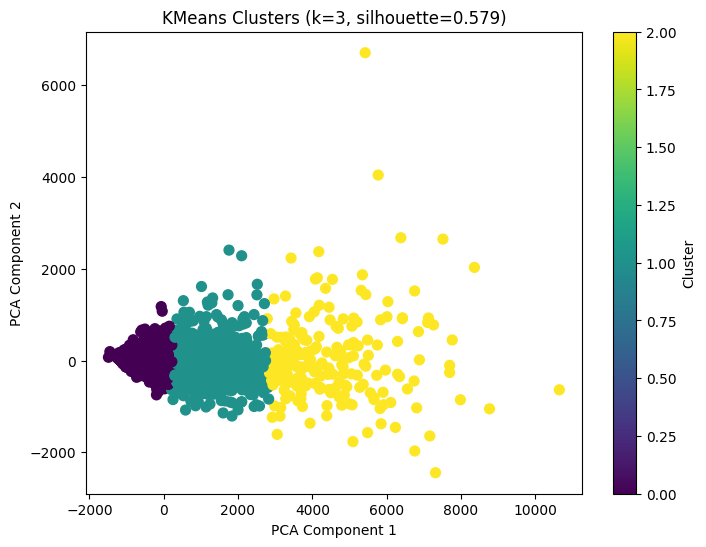

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA ile 2 boyuta indirgeme
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_in)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', s=50)
plt.colorbar(scatter, label="Cluster")
plt.title(f"KMeans Clusters (k={K}, silhouette={sil:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv("../../data/Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB
